# Linear Regression

### What is Linear Regression?
Linear regression is basically the "Hello World" of Machine Learning. It is the easiest ML model to understand and implement. It estimates the value of one variable with respect to another variable. \
The variable we are predicting is the **Dependent** variable, while the variable we are using to predict this value is the **Independent** variable.

### Why Linear Regression?

Linear regression models are relatively simple and can be applied to a variety of fields in business as well as academic studies.
- It is used to predict continuous outcomes based on historical data like forecasting sales, or even predicting stock prices. 
- It is computationally inexpensive, trains quickly, and works exceptionally well when relationship between features is linear, making it ideal for large datasets and giving accurate forecasts.
- Most importantly, it provides a baseline for us to start with before applying more complex models, and forms the foundation for more advanced techniques like regularized regression and neural networks.

### Simple Linear Regression

This is the baseline model with the equation:
$$Y = \beta_0 + \beta_1 x$$
where B0 is the intercept while B1 is the gradient (slope) of the line.

Let's try to implement this using code!

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Creating a random linear looking data:

In [14]:
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.randn(100,1)


In [15]:
X

array([[1.57045349],
       [0.77773661],
       [1.68744109],
       [1.68894141],
       [0.66395291],
       [0.8678799 ],
       [1.50492015],
       [1.20800918],
       [1.59596705],
       [0.87207512],
       [0.67708498],
       [1.87008109],
       [1.07263826],
       [1.85690685],
       [0.67266634],
       [0.18693043],
       [1.66929626],
       [1.92846994],
       [1.86689446],
       [1.58321902],
       [1.19433125],
       [1.05299877],
       [0.97442522],
       [1.03389737],
       [0.53940902],
       [1.75913272],
       [1.73347608],
       [1.59871882],
       [1.50751513],
       [0.40908887],
       [0.41029391],
       [1.27905538],
       [1.79687667],
       [1.34982986],
       [1.61000533],
       [1.71159439],
       [1.46330669],
       [1.4540274 ],
       [0.0982522 ],
       [0.34344464],
       [0.10705973],
       [1.25289629],
       [1.21908491],
       [1.36690076],
       [1.23475665],
       [0.60108631],
       [1.35763246],
       [1.851

In [16]:
y

array([[ 6.73719112],
       [ 6.1085199 ],
       [ 8.61668692],
       [ 8.73124166],
       [ 4.84444299],
       [ 7.7980097 ],
       [ 8.75207338],
       [ 6.52580207],
       [ 7.4849804 ],
       [ 5.87499344],
       [ 6.27816293],
       [ 8.90956181],
       [ 5.80491873],
       [ 8.62064629],
       [ 6.8913009 ],
       [ 6.89808266],
       [ 9.19543092],
       [10.6959853 ],
       [ 9.32272271],
       [ 8.70425993],
       [ 7.56117459],
       [ 7.90314374],
       [ 7.28649064],
       [ 6.90099479],
       [ 5.79317993],
       [ 7.58728312],
       [ 8.68287011],
       [ 8.62032436],
       [ 7.13819605],
       [ 5.1893189 ],
       [ 5.13056177],
       [ 7.78832427],
       [ 8.20717685],
       [ 8.48340372],
       [ 7.59512841],
       [ 9.04521763],
       [ 5.90205529],
       [ 7.39613675],
       [ 5.61202713],
       [ 3.51879666],
       [ 6.74983568],
       [ 6.6561622 ],
       [ 8.56348688],
       [ 8.15930541],
       [ 8.01064683],
       [ 5

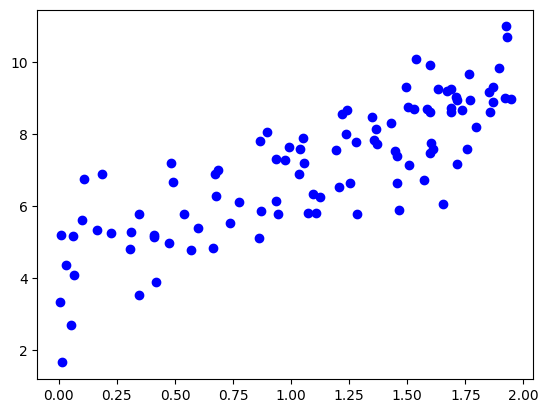

In [18]:
plt.scatter(X,y, color="blue")

plt.show()

Here we try to compute $\theta$ using Numpy's inverse function and the transpose (T), as well as dot() for matrix multiplication.

In [25]:
X_b = np.c_[np.ones((100,1)), X]
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [26]:
theta

array([[4.27779852],
       [2.55814232]])

As we've added some noise in y above, we get values close to 4 and 3

Now, we can make predictions using the $\theta$ we calculated above.

In [23]:
X_new = np.array([[0],[2]])
X_new_b = np.c_[np.ones((2,1)), X_new]
y_predict = X_new_b.dot(theta)

y_predict

array([[4.27779852],
       [9.39408315]])

Plotting our predictions, we have:

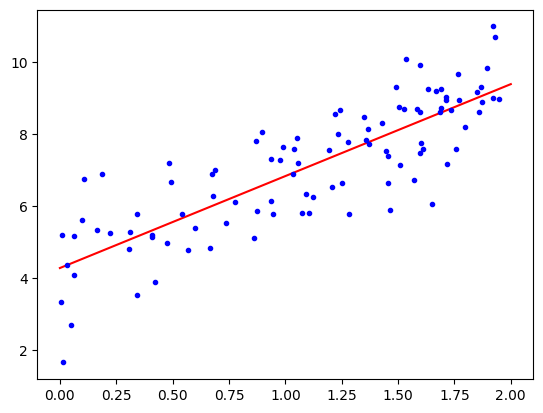

In [24]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")

That was some tedious work to be honest! All of this is simple enough to implement using `scikit-learn`


In [27]:
from sklearn.linear_model import LinearRegression

In [29]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.predict(X_new)

array([[4.27779852],
       [9.39408315]])

We have the same result as the manual implementation we did above!

### Using a custom class for Linear Regression

This class works the same as the methods we implemented above.

In [79]:
class MyLinReg:

    def __init__(self):
        self.m = None
        self.b = None 

    def fit(self, X_train, y_train):

        numerator = 0
        denom = 0

        for i in range(X_train.shape[0]):
            numerator += (X_train[i] - X_train.mean()) * (y_train[i] - y_train.mean())
            denom += (X_train[i] - X_train.mean())**2

        self.m = numerator / denom
        self.b = y_train.mean() - self.m * X_train.mean()
        return self.m, self.b

    def predict(self, X_test):
        return self.m * X_test + self.b

In [80]:
import numpy as np 
import pandas as pd

df = pd.read_csv("IceCreamData.csv")

df.head()

,Temperature,Revenue
0,16.85,423.27
1,42.78,1055.89
2,32.94,798.58
3,26.94,593.57
4,7.02,150.44


In [81]:
X = df.iloc[:,0].values
y = df.iloc[:,1].values

In [82]:
X

array([16.85, 42.78, 32.94, 26.94,  7.02,  7.02,  2.61, 38.98, 27.05,
       31.86,  0.93, 43.65, 37.46,  9.56,  8.18,  8.25, 13.69, 23.61,
       19.44, 13.11, 27.53,  6.28, 13.15, 16.49, 20.52, 35.33,  8.99,
       23.14, 26.66,  2.09, 27.34,  7.67,  2.93, 42.7 , 43.45, 36.38,
       13.71,  4.4 , 30.79, 19.81,  5.49, 22.28,  1.55, 40.92, 11.65,
       29.81, 14.03, 23.4 , 24.6 ,  8.32, 43.63, 34.88, 42.28, 40.27,
       26.91, 41.48,  3.98,  8.82,  2.04, 14.64, 17.49, 12.21, 37.29,
       16.05, 12.64, 24.42,  6.34, 36.1 ,  3.35, 44.41, 34.75,  8.94,
        0.25, 36.7 , 31.81, 32.81, 34.71,  3.33, 16.13,  5.21, 38.84,
       28.05, 14.89,  2.86, 13.99, 14.63, 32.83, 28.69, 39.92, 21.25,
        5.38, 32.1 , 34.24, 25.26, 34.69, 22.22, 23.52, 19.24,  1.14,
        4.86,  1.41, 28.64, 14.15, 22.89, 40.84, 11.22, 18.47, 34.  ,
       10.3 ,  3.46, 13.04,  7.25, 41.84, 36.37, 28.5 , 39.22, 36.17,
        8.4 , 40.17, 24.27, 36.33, 40.32, 14.31,  4.95, 10.26, 19.22,
       36.81, 38.73,

In [83]:
y

array([ 423.27, 1055.89,  798.58,  593.57,  150.44,  219.93,   34.86,
        972.09,  683.76,  704.52,    0.  , 1048.29,  842.24,  311.59,
        140.53,  191.81,  338.63,  553.46,  439.07,  356.95,  581.76,
        172.29,  332.71,  424.02,  520.43,  746.14,  160.77,  604.85,
        633.01,   52.22,  708.55,  215.14,  166.56,  963.69, 1079.51,
        912.54,  326.27,  187.64,  737.25,  537.92,  114.33,  556.88,
        130.93,  834.21,  235.34,  582.07,  332.1 ,  582.47,  647.41,
        226.88, 1061.72,  723.67,  866.09,  905.38,  640.89,  932.62,
         26.84,  229.46,   23.24,  392.19,  438.16,  259.63,  818.7 ,
        336.06,  312.74,  616.18,  131.51,  843.99,   90.24,  957.33,
        784.54,  184.79,   22.48,  771.69,  825.04,  749.94,  753.97,
        126.97,  385.06,  145.57,  908.26,  684.06,  337.56,   77.36,
        331.11,  243.47,  672.99,  728.29,  983.06,  487.97,  189.04,
        748.53,  932.78,  642.33,  782.26,  473.47,  468.84,  467.49,
         31.54,   77

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape

(400,)

In [85]:
mylinreg = MyLinReg()
mylinreg.fit(X_train, y_train)


(np.float64(21.67391040129557), np.float64(39.464499032547565))

In [86]:
X_train[0]

np.float64(38.39)

In [87]:
X_train.mean()

np.float64(22.67145)

In [88]:
mylinreg.predict(42.4)

np.float64(958.4383000474796)

Comparing with scikit-learn's LinearRegression class, we get the EXACT same results!

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = X.reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)
m = model.coef_
b = model.intercept_

print(f'Values for gradient and intercept: {m[0]} , {b}')



Values for gradient and intercept: 21.673910401295576 , 39.46449903254745


Even our prediction result matches, as we have used the exact equation used in the sklearn class

In [90]:
model.predict([[42.4]])

array([958.43830005])